# Day 12 - Correlations and Feature Ideas

## Week 2 topic

- **Topic:** Correlations and feature ideas
- **Summary:** Correlation matrix, scatter matrix, and experimenting with attribute combinations
- **Practice:** Create two new feature ratios and compare correlations

### Learning goals

By the end of this lesson, you should be able to:

1. Read a Pearson correlation matrix without confusing correlation with causation.
2. Use a scatter matrix to inspect distributions and pairwise relationships.
3. Create useful ratio features with safe division.
4. Compare correlations before and after feature engineering.
5. Save analysis outputs so the experiment can be reviewed later.

This notebook uses the California Housing dataset because it contains meaningful numeric attributes such as rooms, bedrooms, occupancy, income, and house value.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 1. Load and Inspect the Day 12 Dataset

The code first looks for a CSV already present in this project. If it is not found, it loads the same California Housing data used in earlier lessons through scikit-learn. Keeping the path configurable makes the notebook reusable with another CSV later.

The target column is `MedHouseVal`, the median house value in units of $100,000.

In [3]:
PROJECT_ROOT = Path.cwd().resolve()
DATA_CANDIDATES = [
    PROJECT_ROOT / "day9_Get_and_Inspect_Data" / "california_housing.csv",
    PROJECT_ROOT.parent / "day9_Get_and_Inspect_Data" / "california_housing.csv",
]

csv_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if csv_path is not None:
    candidate_df = pd.read_csv(csv_path)
    if "MedHouseVal" not in candidate_df.columns and "median_house_value" in candidate_df.columns:
        candidate_df = candidate_df.rename(columns={"median_house_value": "MedHouseVal"})
else:
    candidate_df = None

if candidate_df is not None and "MedHouseVal" in candidate_df.columns:
    df = candidate_df
    data_source = f"CSV: {csv_path}"
else:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame.copy()
    data_source = "scikit-learn: fetch_california_housing (CSV did not include target)"

print("Data source:", data_source)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Data source: scikit-learn: fetch_california_housing (CSV did not include target)
Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Data types:")
df.info()

print("\nMissing values:")
print(df.isna().sum())

print("\nDescriptive statistics:")
df.describe().T

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 2. Create the Day 12 Notebook Folder and File

The notebook is stored in `day12-correlations-and-feature-ideas`. This cell also creates a portable underscore-style output folder named `day_12_correlations_and_feature_ideas` for CSV and image artifacts. It is safe to run repeatedly because `exist_ok=True` avoids an error when the folder already exists.

In [5]:
lesson_folder = PROJECT_ROOT / "day_12_correlations_and_feature_ideas"
lesson_folder.mkdir(parents=True, exist_ok=True)
notebook_artifact_path = lesson_folder / "correlations_and_feature_ideas.ipynb"
print("Artifact folder:", lesson_folder)
print("Suggested notebook path:", notebook_artifact_path)

Artifact folder: C:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\daily learning\day12-correlations-and-feature-ideas\day_12_correlations_and_feature_ideas
Suggested notebook path: C:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\daily learning\day12-correlations-and-feature-ideas\day_12_correlations_and_feature_ideas\correlations_and_feature_ideas.ipynb


## 3. Prepare Numeric Features

Correlation requires numeric values. We select numeric columns and make a copy so that cleaning and feature engineering do not modify the original `df`. Identifier-like columns are excluded when present. Infinite values are converted to missing values before calculating correlations.

In [6]:
numeric_df = df.select_dtypes(include="number").copy()
identifier_columns = [
    column for column in numeric_df.columns
    if column.lower() in {"id", "index", "unnamed: 0"}
]
numeric_df = numeric_df.drop(columns=identifier_columns, errors="ignore")
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

print("Selected numeric columns:", list(numeric_df.columns))
print("Rows with any missing numeric value:", numeric_df.isna().any(axis=1).sum())

Selected numeric columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
Rows with any missing numeric value: 0


## 4. Calculate and Visualize the Correlation Matrix

`DataFrame.corr()` calculates Pearson correlation by default. Pearson correlation measures the **direction and strength of a linear relationship** between two numeric columns. It always falls between `-1` and `1`:

- A value near `+1` means the two columns tend to increase together. On the heatmap, this appears as a strong warm-colored cell.
- A value near `-1` means one column tends to increase when the other decreases. This appears as a strong cool-colored cell.
- A value near `0` means there is little linear relationship. It does not mean the columns are completely unrelated; a curved pattern can still exist.
- The diagonal is always `1.00` because every column is perfectly correlated with itself.
- The matrix is symmetric: the correlation for `MedInc` and `MedHouseVal` is the same as the correlation for `MedHouseVal` and `MedInc`.

### How to read this heatmap

1. Start with the `MedHouseVal` row or column if the goal is house-value prediction.
2. Look for the largest absolute values, not only the largest positive values. A value of `-0.80` is just as strong as `+0.80` in magnitude.
3. Compare the number with the scatter plot. A strong value can be caused by outliers, and a weak Pearson value can hide a nonlinear pattern.
4. Treat correlation as a clue for further investigation, not proof that one variable causes another.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.00,-0.12,0.33,-0.06,0.00,0.02,-0.08,-0.02,0.69
HouseAge,-0.12,1.00,-0.15,-0.08,-0.30,0.01,0.01,-0.11,0.11
AveRooms,0.33,-0.15,1.00,0.85,-0.07,-0.00,0.11,-0.03,0.15
AveBedrms,-0.06,-0.08,0.85,1.00,-0.07,-0.01,0.07,0.01,-0.05
Population,0.00,-0.30,-0.07,-0.07,1.00,0.07,-0.11,0.10,-0.02
AveOccup,0.02,0.01,-0.00,-0.01,0.07,1.00,0.00,0.00,-0.02
Latitude,-0.08,0.01,0.11,0.07,-0.11,0.00,1.00,-0.92,-0.14
Longitude,-0.02,-0.11,-0.03,0.01,0.10,0.00,-0.92,1.00,-0.05
MedHouseVal,0.69,0.11,0.15,-0.05,-0.02,-0.02,-0.14,-0.05,1.00


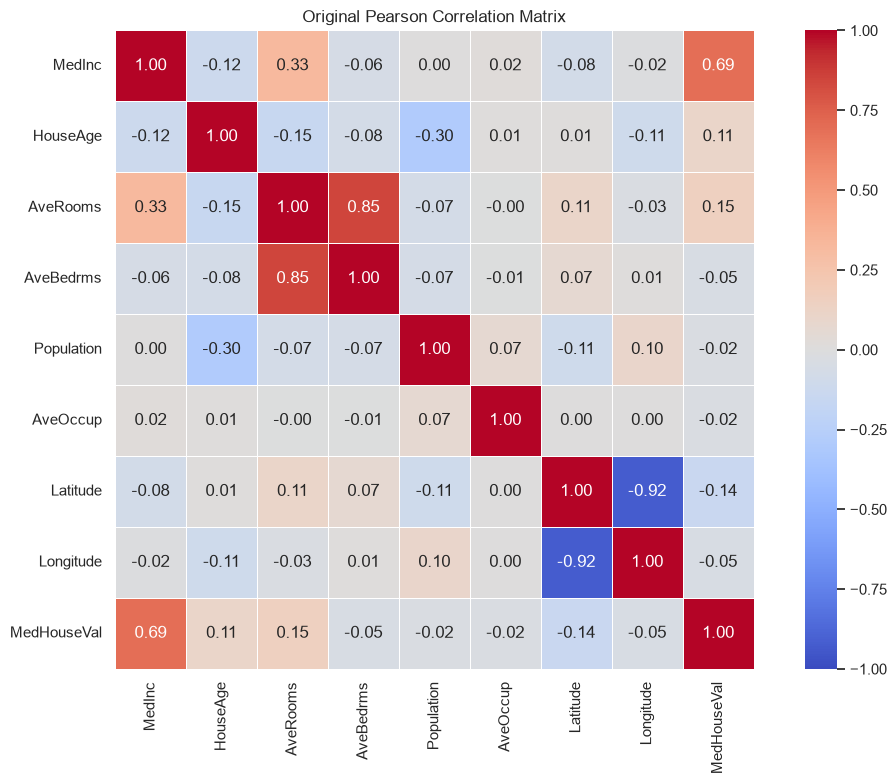

In [7]:
original_corr = numeric_df.corr(method="pearson")
display(original_corr.round(2))

plt.figure(figsize=(11, 8))
sns.heatmap(original_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title("Original Pearson Correlation Matrix")
plt.tight_layout()
original_heatmap_path = lesson_folder / "original_correlation_heatmap.png"
plt.savefig(original_heatmap_path, dpi=150, bbox_inches="tight")
plt.show()

## 5. Analyze Strong Feature Correlations

The matrix repeats each pair twice, so we keep only its upper triangle. Sorting by absolute correlation shows both strong positive and strong negative relationships. If a target is available, we rank its relationships separately.

In [8]:
upper_triangle = original_corr.where(np.triu(np.ones(original_corr.shape), k=1).astype(bool))
strong_pairs = (
    upper_triangle.stack().rename("correlation").to_frame()
    .assign(abs_correlation=lambda table: table["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
)
display(strong_pairs.head(10))

target_column = "MedHouseVal" if "MedHouseVal" in numeric_df.columns else None
if target_column:
    target_correlations = original_corr[target_column].drop(labels=target_column).sort_values(
        key=lambda values: values.abs(), ascending=False
    ).rename("correlation").to_frame()
    target_correlations["abs_correlation"] = target_correlations["correlation"].abs()
    display(target_correlations)
else:
    print("No target column detected.")

correlation  abs_correlation
Latitude   Longitude      -0.924664         0.924664
AveRooms   AveBedrms       0.847621         0.847621
MedInc     MedHouseVal     0.688075         0.688075
           AveRooms        0.326895         0.326895
HouseAge   Population     -0.296244         0.296244
           AveRooms       -0.153277         0.153277
AveRooms   MedHouseVal     0.151948         0.151948
Latitude   MedHouseVal    -0.144160         0.144160
MedInc     HouseAge       -0.119034         0.119034
Population Latitude       -0.108785         0.108785

,correlation,abs_correlation
MedInc,0.688075,0.688075
AveRooms,0.151948,0.151948
Latitude,-0.144160,0.144160
HouseAge,0.105623,0.105623
AveBedrms,-0.046701,0.046701
Longitude,-0.045967,0.045967
Population,-0.024650,0.024650
AveOccup,-0.023737,0.023737


## 6. Create a Scatter Matrix

A scatter matrix puts several small plots into one view. The diagonal plots are **histograms**; the off-diagonal plots are scatter plots for pairs of features.

### How to read a histogram

A histogram groups numeric values into intervals called **bins**. The height of a bar tells us how many observations fall inside that interval. Use it to ask:

- Where is the distribution centered? This gives a quick sense of a typical value.
- Is it spread out or tightly grouped? A wide spread means the feature varies substantially.
- Is it symmetric, left-skewed, or right-skewed? A long tail can affect averages and linear models.
- Are there gaps, multiple peaks, or extreme values? These may indicate subgroups, unusual records, or data-quality issues.

The histogram is about one column at a time. It does **not** tell us whether that feature is related to the target. For relationships, inspect the matching scatter plot and compare its shape with the correlation value.

### How to read the scatter plots

A narrow rising band suggests a positive relationship; a narrow falling band suggests a negative relationship; and a shapeless cloud suggests a weak linear relationship. Transparency (`alpha`) reduces overplotting so dense regions remain visible. We limit the plot to a few useful columns so the patterns are readable rather than overwhelming.

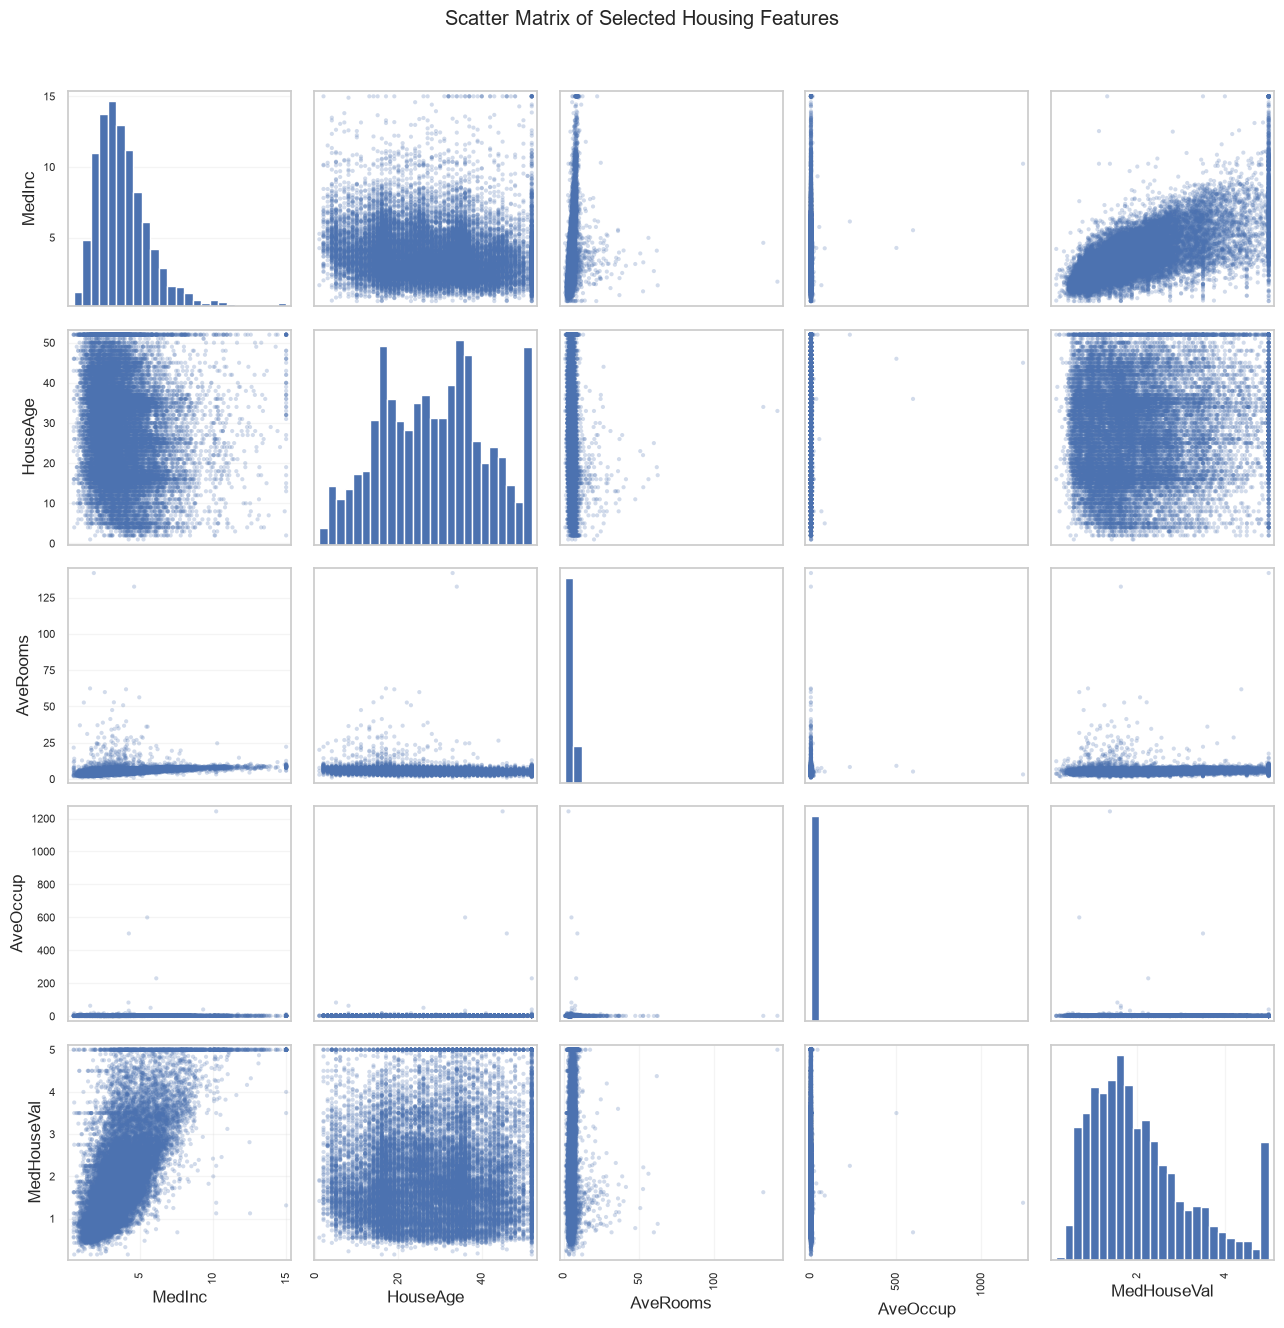

In [9]:
scatter_columns = [column for column in ["MedInc", "HouseAge", "AveRooms", "AveOccup", "MedHouseVal"] if column in df.columns]
if len(scatter_columns) < 3:
    scatter_columns = list(numeric_df.columns[: min(5, len(numeric_df.columns))])

axes = pd.plotting.scatter_matrix(
    df[scatter_columns].dropna(), figsize=(13, 13), diagonal="hist", alpha=0.25,
    hist_kwds={"bins": 25, "edgecolor": "white"}
)
for axis in np.asarray(axes).ravel():
    axis.grid(True, alpha=0.2)
plt.suptitle("Scatter Matrix of Selected Housing Features", y=1.02)
plt.tight_layout()
scatter_matrix_path = lesson_folder / "scatter_matrix.png"
plt.savefig(scatter_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

## Interpretation and Practice

### Correlation matrix checklist

- Which feature has the strongest positive relationship with `MedHouseVal`?
- Which feature has the strongest negative relationship with `MedHouseVal`?
- Are any two predictors highly correlated with each other? If so, they may contain overlapping information.
- Does the scatter plot support what the correlation number suggests?

### Histogram checklist

- Which features are strongly right-skewed?
- Which features contain unusually large or small values?
- Which distributions look concentrated in a narrow range?
- Do you see more than one peak that might represent different groups of observations?

### Important reminder

Correlation and histograms help us understand the data, but they do not by themselves select the best features or prove causation. Use them to form hypotheses, then test those hypotheses with validation data and a model.

### Practice tasks

1. Choose the three strongest correlations with `MedHouseVal` and explain their signs in plain language.
2. Choose one skewed histogram and write down what a long tail might mean for a machine-learning algorithm.
3. Find one pair of predictors with a high absolute correlation and explain why duplicate information might matter during modeling.